# Mouse workflow comparison: notebook 02 versus notebook 03

The healthy mouse controls (`Ctrl1A2`, `Ctrl1A4`) are analysed twice: once in the **mouse-only**
workflow (`02_mouse_only_pseudospace.ipynb`, which co-embeds them with the two AKI samples) and once
in the **cross-species** workflow (`03_human_vs_healthy_mouse.ipynb`, which co-embeds them with the
two human slices). This notebook asks whether the two runs agree, and where they do not.

Because the mouse segmentation and the `Ctrl1A2`/`Ctrl1A4` tubule-by-gene matrices never changed,
the same tubule is identifiable in both runs by `(sample, feature_index)`. Everything below compares
**the same tubules**, not two independent populations.

Sections: (1) configuration, (2) retained tubule sets, (3) coarse label agreement, (4) embedding
geometry, (5) pipeline parameters, (6) how to read this.

## 1. Configuration

In [1]:
from __future__ import annotations

import argparse
import os
import re
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.neighbors import NearestNeighbors

def _find_project_dir() -> Path:
    starts = [Path.cwd().resolve()]
    if "__file__" in globals():
        starts.insert(0, Path(__file__).resolve().parent)
    for start in starts:
        for candidate in (start, *start.parents):
            if (candidate / "pseudospace").is_dir() and (candidate / "data").is_dir():
                return candidate
    raise RuntimeError("Could not locate the repository root containing pseudospace/ and data/")

def _results_root(project_dir: Path) -> Path:
    parser = argparse.ArgumentParser(add_help=False)
    parser.add_argument("--results-root", type=Path)
    args, _ = parser.parse_known_args()
    root = args.results_root or os.environ.get("PSEUDOSPACE_RESULTS_ROOT") or project_dir / "results"
    return Path(root).expanduser().resolve()

PROJECT_DIR = _find_project_dir()
DATA_ROOT = Path(os.environ.get("PSEUDOSPACE_DATA_ROOT", PROJECT_DIR / "data")).expanduser().resolve()
RESULTS_ROOT = _results_root(PROJECT_DIR)

MOUSE_ONLY_RUN = RESULTS_ROOT / "mouse_only_v5" / "all_mouse_tubules_harmony_pass1.h5ad"
CROSS_SPECIES_RUN = RESULTS_ROOT / "human_vs_healthy_mouse" / "cross_species_harmony_pass1.h5ad"
OUTPUT_DIR = RESULTS_ROOT / "mouse_workflow_comparison"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MOUSE_CONTROLS = ("Ctrl1A2", "Ctrl1A4")
# The cross-species workflow removes these before pass-2 Harmony, so they are "not a nephron tubule".
NEPHRON_CLASSES = ("PT", "TAL", "DCT", "CNT_CD")
# Notebook 02 rolls the ascending limb up as 'AL'; notebook 03 calls the same class 'TAL'.
# Bridging them is what makes the two coarse vocabularies comparable at all -- see section 6.
COARSE_BRIDGE = {"AL": "TAL"}
N_SUBSAMPLE = 2500
N_NEIGHBOURS = 15
RANDOM_STATE = 0

for _path in (MOUSE_ONLY_RUN, CROSS_SPECIES_RUN):
    if not _path.exists():
        raise FileNotFoundError(f"Missing {_path} - rebuild that workflow before comparing.")
print("Both pass-1 objects found.")

Both pass-1 objects found.


## 2. Retained tubule sets

Same input matrices, so if the two workflows retain the same tubules the comparison is
apples-to-apples before any label is examined.

In [2]:
def load_run(path: Path) -> pd.DataFrame:
    """obs for the healthy mouse controls, keyed so a tubule can be matched across runs."""
    obj = ad.read_h5ad(path, backed="r")
    missing = [c for c in ("sample", "feature_index", "coarse_class") if c not in obj.obs.columns]
    if missing:
        raise KeyError(f"{path.name} is missing obs columns {missing}")
    obs = pd.DataFrame({
        "sample": obj.obs["sample"].astype(str).to_numpy(),
        "feature_index": obj.obs["feature_index"].astype(int).to_numpy(),
        "coarse_class": obj.obs["coarse_class"].astype(str).to_numpy(),
    })
    del obj
    obs["tubule_key"] = obs["sample"] + "|" + obs["feature_index"].astype(str)
    if obs["tubule_key"].duplicated().any():
        raise ValueError(f"{path.name} has duplicate (sample, feature_index) keys")
    return obs[obs["sample"].isin(MOUSE_CONTROLS)].reset_index(drop=True)

mouse_only = load_run(MOUSE_ONLY_RUN)
cross_species = load_run(CROSS_SPECIES_RUN)

shared_keys = np.intersect1d(mouse_only["tubule_key"], cross_species["tubule_key"])
print(f"healthy-mouse tubules retained   02 = {len(mouse_only):,}   03 = {len(cross_species):,}")
print(f"present in both runs             {len(shared_keys):,}"
      f"   (02-only {len(mouse_only) - len(shared_keys)}, 03-only {len(cross_species) - len(shared_keys)})")

healthy-mouse tubules retained   02 = 17,880   03 = 17,879
present in both runs             17,879   (02-only 1, 03-only 0)


### 2b. Explaining any tubule-set difference

The two workflows do not filter tubules the same way. Notebook 03 applies an absolute cutoff --
`sc.pp.filter_cells(adata_combined, min_genes=MIN_GENES_PER_TUBULE)`, with `MIN_GENES_PER_TUBULE = 100`
-- and it runs that on the **ortholog-restricted shared matrix**, not on the mouse gene space.
Notebook 02 has no tubule-level gene filter at all, only gene-level ones (`MIN_GENE_TUBULE_FRACTION`,
`MIN_GENE_TOTAL_COUNTS`).

A tubule therefore differs only when it is sparse enough that both hold: the ortholog mapping and the
combined matrix's gene-level filters shrink its gene count, and the result lands below 100. In the
current data that is a single tubule, `Ctrl1A4|5556`, with 102 counts over exactly 100 nonzero genes:
`Atp5b` and `Cyp2j5` have no one-to-one ortholog, and four more are too rare to survive the combined
cohort's gene filters, leaving 94 shared genes -- just under the cutoff.

That direction favours notebook 03: a tubule with roughly one UMI per gene is a segmentation sliver
rather than tissue, so dropping it is the more defensible behaviour. Treat the two retained sets as
equivalent for everything meaningfully populated, and read the cell below before comparing counts
across runs. Note also that `MIN_GENES_PER_TUBULE` is a hard cliff with no margin -- 99 shared genes
is dropped, 100 is kept -- so the number of tubules lost will move sharply if the gene space or the
combined-cohort filters ever change.

In [ ]:
# Identify the tubules only one workflow kept, and attribute each to the step that removed it.
only_02 = sorted(set(mouse_only["tubule_key"]) - set(cross_species["tubule_key"]))
only_03 = sorted(set(cross_species["tubule_key"]) - set(mouse_only["tubule_key"]))
print(f"tubules only in 02: {len(only_02)}   only in 03: {len(only_03)}")

if not only_02 and not only_03:
    print("the retained tubule sets are identical")
else:
    shared_obj = ad.read_h5ad(CROSS_SPECIES_RUN, backed="r")
    shared_genes = set(map(str, shared_obj.var_names))
    del shared_obj
    ortholog = pd.read_csv(RESULTS_ROOT / "human_vs_healthy_mouse" / "ortholog_map_used.csv")
    mapped_mouse = set(ortholog["mouse_symbol"].astype(str))

    matrices, rows = {}, []
    for key in only_02 + only_03:
        sample, feature_index = key.split("|")
        if sample not in matrices:
            matrices[sample] = ad.read_h5ad(
                DATA_ROOT / "tubule_by_gene" / f"{sample}_tubule_by_gene_caleb.h5ad")
        obj = matrices[sample]
        values = obj.X[obj.obs["feature_index"].to_numpy() == int(feature_index)]
        values = np.asarray(values.todense()).ravel() if hasattr(values, "todense") else np.asarray(values).ravel()
        genes = np.array(list(map(str, obj.var_names)))[values > 0]
        rows.append({
            "tubule": key,
            "kept_by": "02 only" if key in only_02 else "03 only",
            "total_counts": int(values.sum()),
            "genes_mouse_space": int(len(genes)),
            "genes_shared_space": int(sum(g in shared_genes for g in genes)),
            "no_one_to_one_ortholog": int(sum(g not in mapped_mouse for g in genes)),
            "too_rare_in_combined": int(sum(g in mapped_mouse and g not in shared_genes for g in genes)),
        })
    delta = pd.DataFrame(rows)
    delta.to_csv(OUTPUT_DIR / "tubule_set_delta.csv", index=False)
    print(delta.to_string(index=False))
    print("\nnotebook 03 keeps a tubule only when genes_shared_space >= MIN_GENES_PER_TUBULE; "
          "notebook 02 applies no tubule-level gene cutoff.")

## 3. Coarse label agreement

`coarse_class` is the only label level the two workflows share (notebook 02 also carries fine
segments such as `PT-S1`/`mTAL`, notebook 03 stops at the broad class).

vocabulary 02: ['AL', 'CNT_CD', 'DCT', 'Glomerulus', 'PT', 'SmoothMuscle', 'Stroma', 'Unassigned']
vocabulary 03: ['CNT_CD', 'DCT', 'Glomerulus', 'PT', 'SmoothMuscle', 'TAL', 'Unassigned']

coarse label agreement, raw                 :   51.7%
coarse label agreement, AL bridged to TAL   :   79.4%
nephron-tubule vs not, agreement            :   91.9%

rows = notebook 02 (AL -> TAL), columns = notebook 03
label_03          CNT_CD  DCT  Glomerulus    PT  SmoothMuscle   TAL  Unassigned    All
label_02_bridged                                                                      
CNT_CD              1701    0           0     2             0    14         614   2331
DCT                  654  703           1    10             2     0           0   1370
Glomerulus             0    0         222     0             0     0           0    222
PT                    31   29          13  6411             6    23         125   6638
SmoothMuscle           0    0           0     0           101     0    

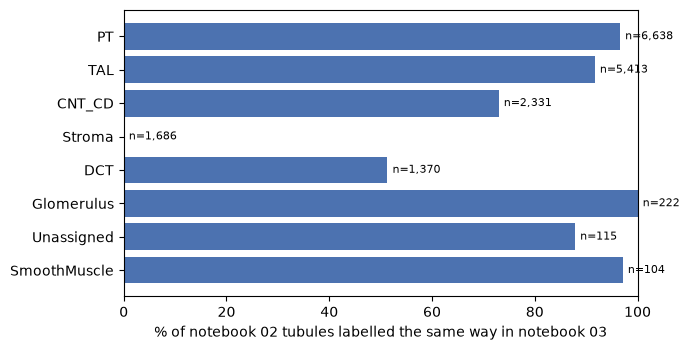

In [3]:
paired = pd.DataFrame({"tubule_key": shared_keys})
paired = paired.merge(
    mouse_only[["tubule_key", "coarse_class"]].rename(columns={"coarse_class": "label_02"}),
    on="tubule_key", how="left",
).merge(
    cross_species[["tubule_key", "coarse_class"]].rename(columns={"coarse_class": "label_03"}),
    on="tubule_key", how="left",
)
paired["label_02_bridged"] = paired["label_02"].replace(COARSE_BRIDGE)
paired["is_nephron_02"] = paired["label_02_bridged"].isin(NEPHRON_CLASSES)
paired["is_nephron_03"] = paired["label_03"].isin(NEPHRON_CLASSES)
paired.to_csv(OUTPUT_DIR / "paired_tubule_labels.csv", index=False)

print("vocabulary 02:", sorted(mouse_only["coarse_class"].unique()))
print("vocabulary 03:", sorted(cross_species["coarse_class"].unique()))
print()
print(f"coarse label agreement, raw                 : {(paired['label_02'] == paired['label_03']).mean():7.1%}")
print(f"coarse label agreement, AL bridged to TAL   : {(paired['label_02_bridged'] == paired['label_03']).mean():7.1%}")
print(f"nephron-tubule vs not, agreement            : {(paired['is_nephron_02'] == paired['is_nephron_03']).mean():7.1%}")

cross_tab = pd.crosstab(paired["label_02_bridged"], paired["label_03"], margins=True)
cross_tab.to_csv(OUTPUT_DIR / "coarse_label_crosstab.csv")
print()
print("rows = notebook 02 (AL -> TAL), columns = notebook 03")
print(cross_tab.to_string())

per_class = (paired.assign(match=paired["label_02_bridged"] == paired["label_03"])
             .groupby("label_02_bridged")
             .agg(n_tubules=("match", "size"), agreement=("match", "mean"))
             .sort_values("n_tubules", ascending=False))
per_class.to_csv(OUTPUT_DIR / "per_class_agreement.csv")
print()
print(per_class.to_string())

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(per_class.index, 100 * per_class["agreement"], color="#4c72b0")
ax.set_xlabel("% of notebook 02 tubules labelled the same way in notebook 03")
ax.set_xlim(0, 100)
for y, (n, a) in enumerate(zip(per_class["n_tubules"], per_class["agreement"])):
    ax.text(100 * a + 1, y, f"n={n:,}", va="center", fontsize=8)
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "per_class_agreement.png", dpi=160)
plt.show()

## 4. Embedding geometry

Harmony embeddings from two different cohorts are not directly comparable axis-by-axis, so the
comparison is rotation-invariant: the Spearman correlation of pairwise distances, and the fraction
of each tubule's k nearest neighbours that are shared between runs. `X_pca` is included to separate
differences that come from the feature space from those added by Harmony.

In [4]:
def embeddings(path: Path, key_order: np.ndarray, names=("X_pca", "X_harmony")) -> dict:
    obj = ad.read_h5ad(path, backed="r")
    obs = pd.DataFrame({
        "sample": obj.obs["sample"].astype(str).to_numpy(),
        "feature_index": obj.obs["feature_index"].astype(int).to_numpy(),
    })
    mask = obs["sample"].isin(MOUSE_CONTROLS).to_numpy()
    obs = obs[mask].copy()
    obs["tubule_key"] = obs["sample"] + "|" + obs["feature_index"].astype(str)
    index = pd.Index(obs["tubule_key"])
    if index.has_duplicates:
        raise ValueError(f"{path.name} has duplicate (sample, feature_index) keys")
    order = index.get_indexer(key_order)
    if (order < 0).any():
        raise KeyError(f"{path.name} is missing {int((order < 0).sum())} requested tubules")
    out = {name: np.asarray(obj.obsm[name])[mask][order] for name in names if name in obj.obsm}
    del obj
    return out

key_order = np.sort(shared_keys)
emb_02 = embeddings(MOUSE_ONLY_RUN, key_order)
emb_03 = embeddings(CROSS_SPECIES_RUN, key_order)

rng = np.random.default_rng(RANDOM_STATE)
sub = rng.choice(len(key_order), size=min(N_SUBSAMPLE, len(key_order)), replace=False)
k = min(N_NEIGHBOURS, len(sub) - 1)
rows = []
for name in sorted(set(emb_02) & set(emb_03)):
    a, b = emb_02[name][sub], emb_03[name][sub]
    da = np.linalg.norm(a[:, None, :] - a[None, :, :], axis=-1)
    db = np.linalg.norm(b[:, None, :] - b[None, :, :], axis=-1)
    upper = np.triu_indices(len(sub), k=1)
    neighbours_a = NearestNeighbors(n_neighbors=k + 1).fit(a).kneighbors(return_distance=False)[:, 1:]
    neighbours_b = NearestNeighbors(n_neighbors=k + 1).fit(b).kneighbors(return_distance=False)[:, 1:]
    overlap = np.mean([len(set(x) & set(y)) / k for x, y in zip(neighbours_a, neighbours_b)])
    rows.append({"embedding": name,
                 "distance_spearman": round(float(spearmanr(da[upper], db[upper]).statistic), 3),
                 f"mean_{k}nn_overlap": round(float(overlap), 3),
                 "n_tubules": len(sub)})
geometry = pd.DataFrame(rows)
geometry.to_csv(OUTPUT_DIR / "embedding_geometry.csv", index=False)
print(geometry.to_string(index=False))

embedding  distance_spearman  mean_15nn_overlap  n_tubules
X_harmony              0.916              0.331       2500
    X_pca              0.945              0.361       2500


## 5. Pipeline parameters

The load-bearing constants are read straight out of the two generated `.py` mirrors, so this table
cannot drift from the code.

In [5]:
ASSIGNMENT = re.compile(r"^([A-Z][A-Z0-9_]*)\s*=\s*(.+?)\s*$", re.M)

def _assignments(path: Path):
    return list(ASSIGNMENT.finditer(path.read_text(encoding="utf-8")))

def scalar_constants(path: Path) -> dict:
    """Comparable top-level scalars: containers, paths and inline comments are dropped."""
    out = {}
    for match in _assignments(path):
        # Strip the trailing inline comment first, otherwise '0.7  # why' != '0.7' and identical
        # settings get reported as differences.
        value = re.split(r"\s+#", match.group(2), maxsplit=1)[0].strip()
        if not value or value[:1] in "{[(" or ";" in value or "/" in value or "Path(" in value:
            continue
        out[match.group(1)] = value
    return out

def raw_constants(path: Path) -> dict:
    """Every top-level assignment, comment-stripped. Paths included; display only, never compared."""
    return {m.group(1): re.split(r"\s+#", m.group(2), maxsplit=1)[0].strip()
            for m in _assignments(path)}

NOTABLE = [
    "NORMALIZE_TARGET_SUM", "N_HVGS", "N_NEIGHBORS", "COARSE_RESOLUTION", "RANDOM_STATE",
    "BATCH_KEY", "HARMONY_THETA", "HARMONY_LAMBDA", "HARMONY_MAX_ITER", "HARMONY_N_PCS",
    "HARMONY_NEIGHBORS_N", "MIN_GENE_TUBULE_FRACTION", "MIN_GENES_PER_TUBULE",
    "ORTHOLOG_TABLE_PATH", "HARMONY_EXPECTED_VERSION",
]
MIRROR_02 = PROJECT_DIR / "analysis" / "mouse_only_pseudospace.py"
MIRROR_03 = PROJECT_DIR / "analysis" / "human_vs_healthy_mouse.py"
cfg_02, cfg_03 = scalar_constants(MIRROR_02), scalar_constants(MIRROR_03)
raw_02, raw_03 = raw_constants(MIRROR_02), raw_constants(MIRROR_03)

common = sorted(set(cfg_02) & set(cfg_03))
identical = [k for k in common if cfg_02[k] == cfg_03[k]]
print(f"comparable top-level scalars: 02 = {len(cfg_02)}, 03 = {len(cfg_03)}, "
      f"shared = {len(common)}, shared and identical = {len(identical)}")
print(f"constants only in 02: {len(set(raw_02) - set(raw_03))}   "
      f"only in 03: {len(set(raw_03) - set(raw_02))}")
print()
print("notable settings (- = absent from that workflow)")
for key in NOTABLE:
    print(f"  {key:26} 02={raw_02.get(key, '-'):>38}   03={raw_03.get(key, '-'):>38}")

differing = pd.DataFrame([{"parameter": k, "notebook_02": cfg_02[k], "notebook_03": cfg_03[k]}
                          for k in common if cfg_02[k] != cfg_03[k]])
differing.to_csv(OUTPUT_DIR / "pipeline_parameter_diff.csv", index=False)
print()
print("comparable constants whose values differ:")
print(differing.to_string(index=False) if len(differing) else "  (none)")

inputs = pd.DataFrame({
    "workflow": ["02 mouse-only", "03 cross-species"],
    "cohort": ["Ctrl1A2, Ctrl1A4, IR2A2, IR2A4", "Ctrl1A2, Ctrl1A4, HUK1_COR1, HUK1_MED1"],
    "feature_space": ["all mouse genes", "mouse genes restricted to human<->mouse HCOP orthologs"],
    "label_vocabulary": ["fine (PT-S1/S2/S3, cTAL/mTAL, Stroma, AL)", "coarse (PT, TAL, DCT, CNT_CD)"],
})
inputs.to_csv(OUTPUT_DIR / "workflow_input_summary.csv", index=False)
print()
print(inputs.to_string(index=False))

comparable top-level scalars: 02 = 54, 03 = 30, shared = 25, shared and identical = 24
constants only in 02: 89   only in 03: 22

notable settings (- = absent from that workflow)
  NORMALIZE_TARGET_SUM       02=                                   1e4   03=                                   1e4
  N_HVGS                     02=                                  2000   03=                                  2000
  N_NEIGHBORS                02=                                    30   03=                                    30
  COARSE_RESOLUTION          02=                                   0.7   03=                                   0.7
  RANDOM_STATE               02=                                     0   03=                                     0
  BATCH_KEY                  02=                              'sample'   03=                              'sample'
  HARMONY_THETA              02=                                     6   03=                                     6
  HARMONY_LAMBDA

## 6. How to read this

- **The tubule sets agree.** Both workflows retain essentially the same healthy-mouse tubules, so
  the comparison is between the same cells, not two populations. Confirm the counts in section 2
  before quoting any downstream number.
- **Agreement is not 100%, and should not be expected to be.** The two workflows differ in three
  independent ways: the feature space (all mouse genes versus human-mouse orthologs only), the
  co-embedded cohort (two AKI mouse samples versus two human slices, which changes what Harmony
  corrects against), and the label vocabulary. Section 5 prints those settings.
- **The local geometry differs even though the global geometry does not.** A high distance
  correlation with a low neighbour overlap means tubules sit in broadly the same space but their
  local neighbourhoods are reshuffled - and Leiden clusters off the neighbour graph, so this is the
  mechanism behind any label disagreement. Compare `X_pca` with `X_harmony` in section 4 to see how
  much of that originates before Harmony.
- **`AL` -> `TAL` is a bridging assumption, not a measurement.** Notebook 02's coarse rollup emits
  `AL` where notebook 03 emits `TAL`. If those are meant to be distinct classes, the raw agreement
  in section 3 is the number to quote and the interpretation changes.
- **`Stroma` exists only in notebook 02.** Where the label sets do not overlap the disagreement is
  a vocabulary gap rather than a biological one, but it is not harmless: some of notebook 02's
  stromal tubules are called nephron segments in notebook 03. Inspect the cross-tab rather than the
  single agreement percentage.
- **These are descriptive comparisons of one clustering each.** Nothing here is a calibrated test of
  either workflow's accuracy, and neither label set is ground truth.